# Industrial Predictive Maintenance - Exploratory Data Analysis

This notebook explores industrial sensor data to understand machine failure patterns and identify operational indicators useful for predictive maintenance systems.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset Overview

Understanding dataset dimensions, feature types, and statistical characteristics.

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
failure_type = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for failure in failure_type:
    print(df[failure].value_counts())

TWF
0    9954
1      46
Name: count, dtype: int64
HDF
0    9885
1     115
Name: count, dtype: int64
PWF
0    9905
1      95
Name: count, dtype: int64
OSF
0    9902
1      98
Name: count, dtype: int64
RNF
0    9981
1      19
Name: count, dtype: int64


## Failure Mode Distribution

Analyzing the occurrence frequency of different machine failure modes.

In [7]:
#Failure Mode Frequencies
mfr = pd.Series({'Machine failure':df['Machine failure'].sum()*100/df['Machine failure'].count()})
for i in failure_type:
    fr = df[failure_type].sum()*100/df[failure_type].count()
fr = pd.concat([fr,mfr])
print(fr)

TWF                0.46
HDF                1.15
PWF                0.95
OSF                0.98
RNF                0.19
Machine failure    3.39
dtype: float64


## Failure Rate Analysis

Calculating percentage occurrence of each failure mode to understand class imbalance and dominant operational risks.

In [8]:
mfr = pd.Series({
    'Machine Failure': df['Machine failure'].mean()*100,
    'TWF': df['TWF'].mean()*100,
    'HDF': df['HDF'].mean()*100,
    'PWF': df['PWF'].mean()*100,
    'OSF': df['OSF'].mean()*100,
    'RNF': df['RNF'].mean()*100
})

mfr.sort_values(ascending=False)

Machine Failure    3.39
HDF                1.15
OSF                0.98
PWF                0.95
TWF                0.46
RNF                0.19
dtype: float64

## Multiple Failure Analysis

Checking whether multiple failure mechanisms can occur simultaneously within the same operational condition.

In [9]:
multi_failure = df[failure_type]

df['multi_failure'] = multi_failure.sum(axis=1)

df[df['multi_failure'] > 1]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,multi_failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0,2
1324,1325,M16184,M,298.8,310.1,1243,74.5,194,1,0,0,1,1,0,2
1496,1497,L48676,L,298.0,308.7,1268,69.4,189,1,0,0,1,1,0,2
3611,3612,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1,2
3854,3855,L51034,L,302.4,311.0,1338,67.6,194,1,0,0,1,1,0,2
3943,3944,L51123,L,302.3,311.4,1333,66.7,205,1,0,0,1,1,0,2
4254,4255,L51434,L,302.6,311.0,1284,68.0,114,1,0,1,1,0,0,2
4342,4343,M19202,M,301.7,309.8,1284,68.2,111,1,0,1,1,0,0,2
4370,4371,L51550,L,302.0,309.9,1308,57.6,197,1,0,1,0,1,0,2
4383,4384,L51563,L,301.7,309.5,1298,65.5,229,1,0,1,0,1,0,2


## Sensor Behavior Analysis

Comparing operational sensor distributions between failed and healthy machines.

In [10]:
sensor_cols = [
    'Tool wear [min]',
    'Torque [Nm]',
    'Rotational speed [rpm]',
    'Process temperature [K]'
]

## Relationship Analysis

Exploring interactions between operational variables to identify high-risk operating regions associated with machine failures.

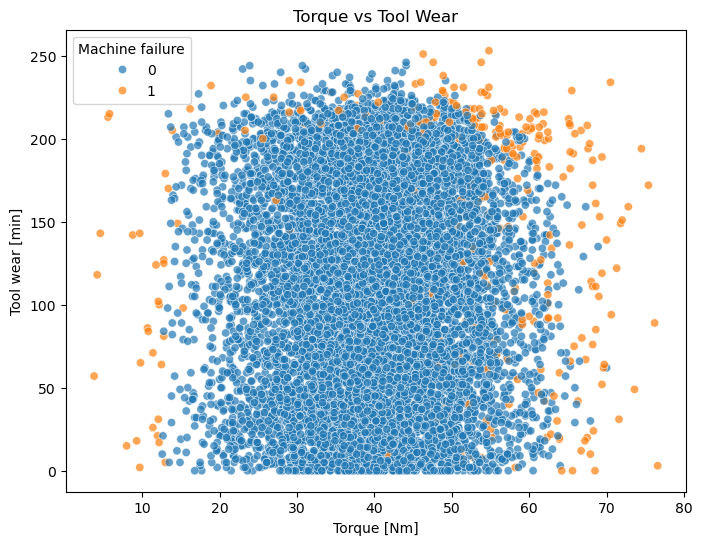

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Torque [Nm]',
    y='Tool wear [min]',
    hue='Machine failure',
    data=df,
    alpha=0.7
)

plt.title('Torque vs Tool Wear')
plt.show()

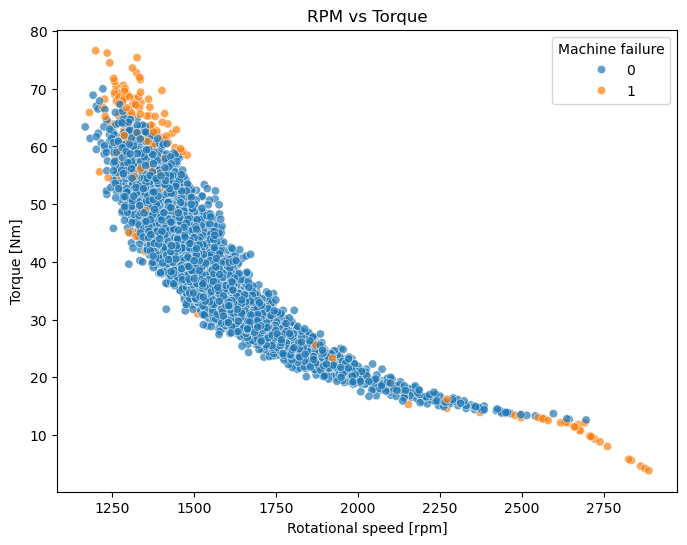

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    data=df,
    alpha=0.7
)

plt.title('RPM vs Torque')
plt.show()

## Feature Engineering

Creating physics-informed operational indicators to better represent thermal efficiency and mechanical power conditions.

In [13]:


df['temp_diff'] = (
    df['Process temperature [K]']
    - df['Air temperature [K]']
)

df['estimated_power'] = (
    df['Torque [Nm]']
    * (2 * np.pi * df['Rotational speed [rpm]'] / 60)
)

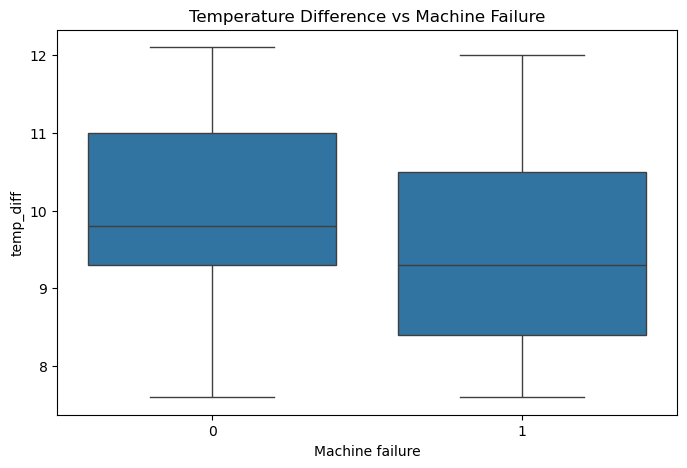

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='temp_diff',
    data=df
)

plt.title('Temperature Difference vs Machine Failure')

plt.show()

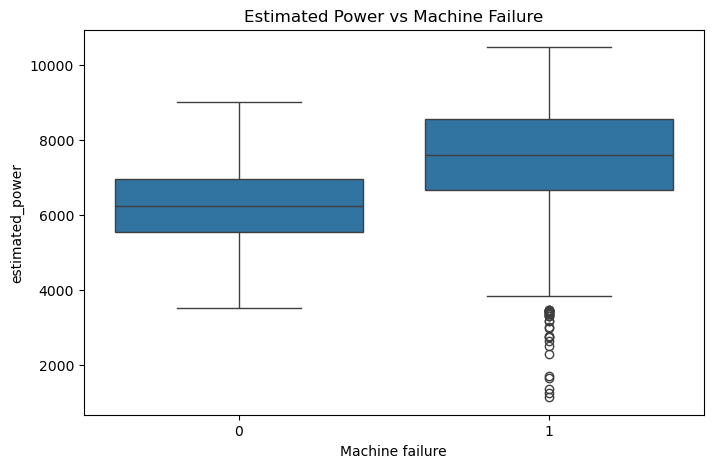

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='estimated_power',
    data=df
)

plt.title('Estimated Power vs Machine Failure')

plt.show()

In [16]:
keep_cols = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temp_diff',
    'estimated_power',
    'Machine failure'
]

model_df = df[keep_cols]

model_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff,estimated_power,Machine failure
0,M,298.1,308.6,1551,42.8,0,10.5,6951.590560,0
1,L,298.2,308.7,1408,46.3,3,10.5,6826.722724,0
2,L,298.1,308.5,1498,49.4,5,10.4,7749.387543,0
3,L,298.2,308.6,1433,39.5,7,10.4,5927.504659,0
4,L,298.2,308.7,1408,40.0,9,10.5,5897.816608,0


In [17]:
model_df.to_csv("../data/processed_ai4i.csv", index=False)